# 📊 Model Evaluation — Hybrid vs Baselines

Compare four recommendation strategies:
1. **Popularity Baseline** — recommend most-reviewed games
2. **Content-Based Only** — TF-IDF + cosine similarity
3. **Collaborative Filtering Only** — Truncated SVD
4. **Hybrid** — CF + CB + Wilson score

Metrics:
- **Precision@K** — fraction of recommendations that are relevant
- **Recall@K** — fraction of relevant items captured
- **NDCG@K** — ranking quality (position-sensitive)
- **Coverage** — catalog diversity (% of games recommended)
- **Novelty** — how surprising/non-obvious the recommendations are

In [1]:
import sys
sys.path.insert(0, '..')

import logging
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s', datefmt='%H:%M:%S')
sns.set_theme(style='whitegrid', palette='muted')

from src.data.loader import load_and_prepare
from src.data.features import prepare_all_features
from src.models.content_based import ContentBasedEngine
from src.models.collaborative import CollaborativeFilteringEngine
from src.models.wilson_score import compute_game_quality_scores
from src.models.hybrid import HybridRecommender
from src.evaluation import compare_recommenders

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data & Train Models

In [2]:
t0 = time.time()

# Load and prepare
data = load_and_prepare('../data/raw')
data = prepare_all_features(data)

# Fit content-based
cb_engine = ContentBasedEngine(max_features=5000)
cb_engine.fit(data['games'])

# Fit collaborative filtering
cf_engine = CollaborativeFilteringEngine(n_components=100)
cf_engine.fit(data['interaction_matrix'], data['user_to_idx'], data['game_to_idx'])

# Compute Wilson scores
games = compute_game_quality_scores(data['games'])

# Fit hybrid
hybrid = HybridRecommender(wilson_weight=0.15)
hybrid.fit(cf_engine, cb_engine, games, data['train'])

print(f'All models trained in {time.time() - t0:.1f}s')

00:13:36 | INFO | Loading games.csv...
00:13:36 | INFO |   → 50,872 games, columns: ['app_id', 'title', 'date_release', 'win', 'mac', 'linux', 'rating', 'positive_ratio', 'user_reviews', 'price_final', 'price_original', 'discount', 'steam_deck']
00:13:36 | INFO | Loading games_metadata.json...
00:13:36 | INFO |   → metadata for 50,872 games
00:13:36 | INFO | Loading recommendations.csv...
00:13:49 | INFO |   → 41,154,794 recommendations
00:13:49 | INFO | Loading users.csv...
00:13:51 | INFO |   → 14,306,064 users
00:13:51 | INFO |   → 49,628/50,872 games have tags
00:14:04 | INFO |   → converged after 6 iterations
00:14:04 | INFO | Filtered interactions: 41,154,794 → 22,286,984 (54.2% retained)
00:14:04 | INFO |   → 1,905,448 users, 22,676 games remaining
00:14:14 | INFO | Train: 18,397,299 | Test: 3,889,685
00:14:16 | INFO | Final dataset: 22,676 games, 1,905,448 users, 18,397,299 train + 3,889,685 test interactions
00:14:16 | INFO | Engagement scores: mean=3.62, median=3.81, max=7.91

All models trained in 85.4s


## 2. Define Recommendation Strategies

Each strategy is a function: `(user_id, n) → list[app_id]`

In [3]:
# --- Popularity Baseline ---
# Simply recommend the most-reviewed games the user hasn't seen
popular_games = (
    data['train'].groupby('app_id').size()
    .sort_values(ascending=False)
    .index.tolist()
)
user_history_cache = data['train'].groupby('user_id')['app_id'].apply(set).to_dict()

def popularity_recommend(user_id, n):
    seen = user_history_cache.get(user_id, set())
    recs = [g for g in popular_games if g not in seen][:n]
    return recs

# --- Content-Based Only ---
def cb_recommend(user_id, n):
    history = user_history_cache.get(user_id, set())
    if not history:
        return []
    recs = cb_engine.recommend_for_user(list(history), n=n, exclude_ids=history)
    return [r['app_id'] for r in recs]

# --- Collaborative Filtering Only ---
def cf_recommend(user_id, n):
    recs = cf_engine.recommend_for_user(user_id, n=n)
    return [r['app_id'] for r in recs]

# --- Hybrid ---
def hybrid_recommend(user_id, n):
    recs = hybrid.recommend(user_id, n=n, explain=False)
    return [r['app_id'] for r in recs]

strategies = {
    'Popularity': popularity_recommend,
    'Content-Based': cb_recommend,
    'Collaborative (SVD)': cf_recommend,
    'Hybrid (Ours)': hybrid_recommend,
}

print(f'Defined {len(strategies)} strategies.')

Defined 4 strategies.


## 3. Run Evaluation

Evaluating on a sample of 5,000 users across K = 5, 10, 20.  
This may take several minutes.

In [4]:
t0 = time.time()

results_df = compare_recommenders(
    strategies,
    test_data=data['test'],
    train_data=data['train'],
    k_values=[5, 10, 20],
    n_sample_users=5000,
)

print(f'\nEvaluation completed in {time.time() - t0:.1f}s')

00:15:17 | INFO | 
00:15:17 | INFO | Evaluating: Popularity
00:15:17 | INFO | ==================================================
00:15:17 | INFO | Evaluating on 5,000 sampled users...
00:15:17 | INFO |   Progress: 1000/5000
00:15:18 | INFO |   Progress: 2000/5000
00:15:18 | INFO |   Progress: 3000/5000
00:15:19 | INFO |   Progress: 4000/5000
00:15:19 | INFO |   Progress: 5000/5000
00:15:19 | INFO | 
00:15:19 | INFO | Evaluating: Content-Based
00:15:19 | INFO | ==================================================
00:15:19 | INFO | Evaluating on 5,000 sampled users...
00:15:22 | INFO |   Progress: 1000/5000
00:15:24 | INFO |   Progress: 2000/5000
00:15:27 | INFO |   Progress: 3000/5000
00:15:29 | INFO |   Progress: 4000/5000
00:15:32 | INFO |   Progress: 5000/5000
00:15:32 | INFO | 
00:15:32 | INFO | Evaluating: Collaborative (SVD)
00:15:32 | INFO | ==================================================
00:15:32 | INFO | Evaluating on 5,000 sampled users...
00:15:33 | INFO |   Progress: 1000/5


Evaluation completed in 74.0s


In [5]:
# Display results table
display_cols = [
    'precision@5', 'precision@10', 'precision@20',
    'recall@5', 'recall@10', 'recall@20',
    'ndcg@5', 'ndcg@10', 'ndcg@20',
    'coverage', 'novelty',
]
display_df = results_df[[c for c in display_cols if c in results_df.columns]].copy()

# Format as percentages where appropriate
for col in display_df.columns:
    if col != 'novelty':
        display_df[col] = display_df[col].map(lambda x: f'{x:.4f}')
    else:
        display_df[col] = display_df[col].map(lambda x: f'{x:.2f}')

print('\n' + '='*80)
print('RECOMMENDATION STRATEGY COMPARISON')
print('='*80)
display(display_df)


RECOMMENDATION STRATEGY COMPARISON


,precision@5,precision@10,precision@20,recall@5,recall@10,recall@20,ndcg@5,ndcg@10,ndcg@20,coverage,novelty
Strategy,,,,,,,,,,,
Popularity,0.0083,0.0063,0.0047,0.0264,0.0390,0.0581,0.0172,0.0214,0.0266,0.0015,8.01
Content-Based,0.0038,0.0030,0.0026,0.0097,0.0155,0.0273,0.0075,0.0094,0.0126,0.2398,12.17
Collaborative (SVD),0.0100,0.0089,0.0068,0.0317,0.0544,0.0807,0.0236,0.0315,0.0389,0.0256,9.72
Hybrid (Ours),0.0098,0.0085,0.0066,0.0314,0.0494,0.0732,0.0232,0.0296,0.0365,0.1058,10.06


## 4. Visualizations

00:16:31 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
00:16:31 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
00:16:31 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
00:16:31 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
00:16:31 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the

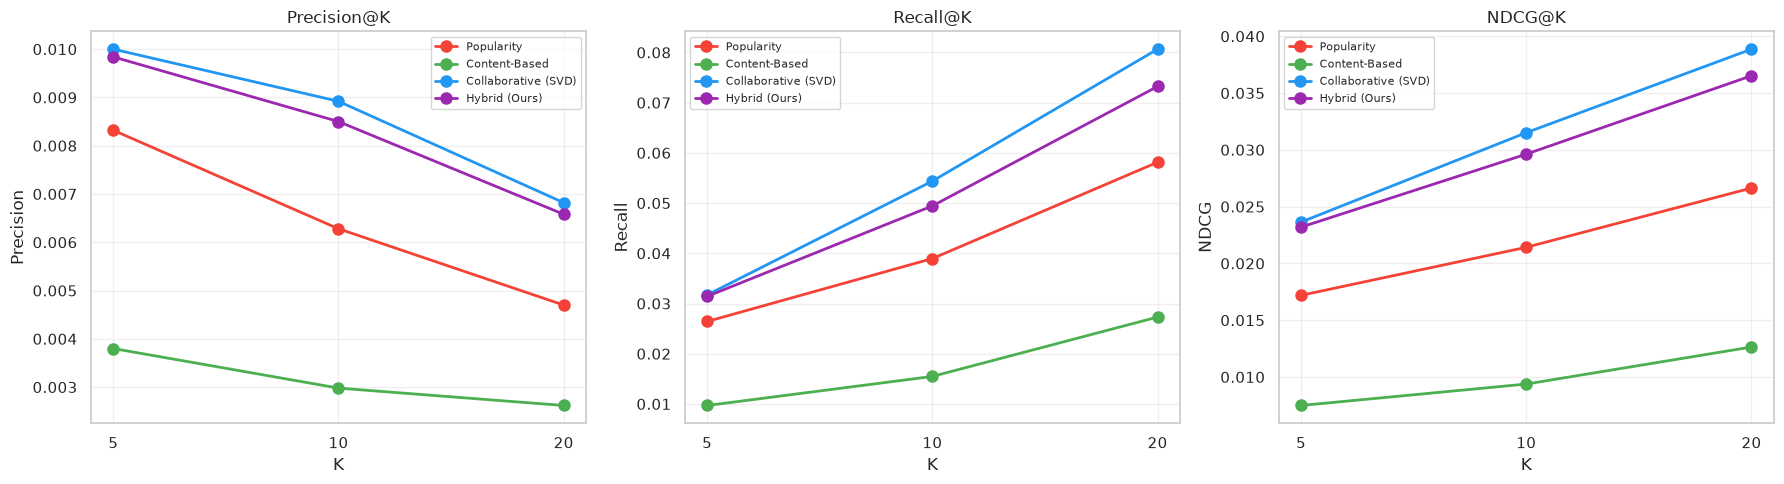

In [6]:
# Precision@K comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_groups = [
    ('Precision@K', ['precision@5', 'precision@10', 'precision@20']),
    ('Recall@K', ['recall@5', 'recall@10', 'recall@20']),
    ('NDCG@K', ['ndcg@5', 'ndcg@10', 'ndcg@20']),
]

colors = {'Popularity': '#f44336', 'Content-Based': '#4CAF50', 
          'Collaborative (SVD)': '#2196F3', 'Hybrid (Ours)': '#9C27B0'}

for ax, (title, cols) in zip(axes, metric_groups):
    available_cols = [c for c in cols if c in results_df.columns]
    if not available_cols:
        continue
    plot_data = results_df[available_cols].T
    k_labels = [c.split('@')[1] for c in available_cols]
    
    for strategy in plot_data.columns:
        ax.plot(k_labels, plot_data[strategy], marker='o', linewidth=2,
                label=strategy, color=colors.get(strategy, None), markersize=8)
    
    ax.set_xlabel('K')
    ax.set_ylabel(title.split('@')[0])
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../assets/ranking_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

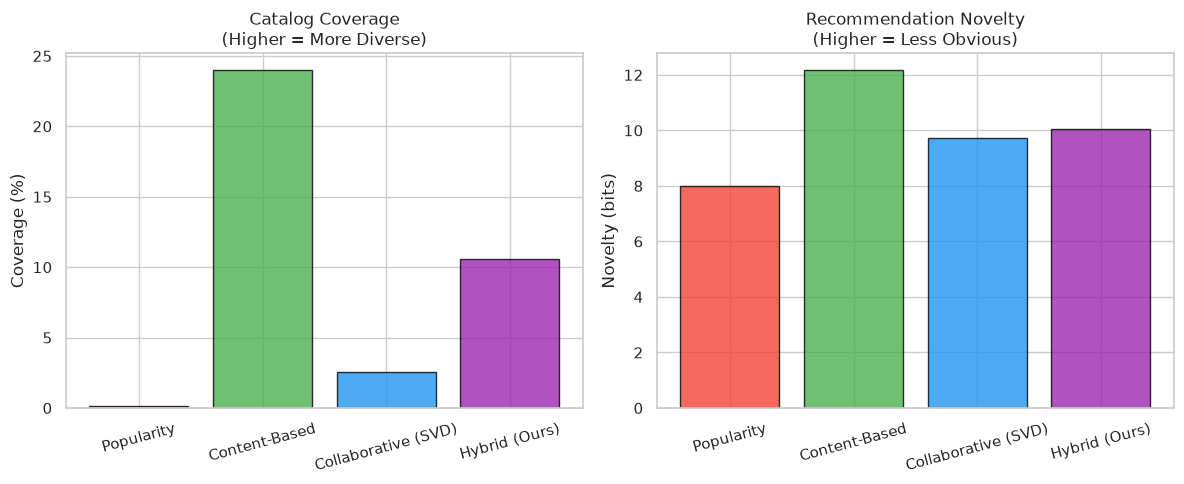

In [7]:
# Coverage and Novelty comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

strategy_names = results_df.index.tolist()
bar_colors = [colors.get(s, '#666') for s in strategy_names]

# Coverage
if 'coverage' in results_df.columns:
    axes[0].bar(strategy_names, results_df['coverage'] * 100, color=bar_colors, edgecolor='black', alpha=0.8)
    axes[0].set_ylabel('Coverage (%)')
    axes[0].set_title('Catalog Coverage\n(Higher = More Diverse)')
    axes[0].tick_params(axis='x', rotation=15)

# Novelty  
if 'novelty' in results_df.columns:
    axes[1].bar(strategy_names, results_df['novelty'], color=bar_colors, edgecolor='black', alpha=0.8)
    axes[1].set_ylabel('Novelty (bits)')
    axes[1].set_title('Recommendation Novelty\n(Higher = Less Obvious)')
    axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../assets/coverage_novelty.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cold-Start Analysis

Compare performance on users grouped by activity level.  
The hybrid system should maintain performance on warm/cold users where pure CF struggles.

In [8]:
from src.evaluation import evaluate_recommender

# Group test users by activity level
user_train_counts = data['train'].groupby('user_id').size()
test_user_ids = data['test']['user_id'].unique()

# Segment users
warm_users = user_train_counts[
    (user_train_counts >= 5) & (user_train_counts < 10)
].index
warm_users = np.intersect1d(warm_users, test_user_ids)

active_users = user_train_counts[user_train_counts >= 10].index
active_users = np.intersect1d(active_users, test_user_ids)

print(f'Warm users (5-9 reviews):  {len(warm_users):,}')
print(f'Active users (10+ reviews): {len(active_users):,}')

Warm users (5-9 reviews):  964,077
Active users (10+ reviews): 506,037


In [9]:
# Evaluate on warm users (where cold-start matters most)
warm_test = data['test'][data['test']['user_id'].isin(warm_users)]
active_test = data['test'][data['test']['user_id'].isin(active_users)]

segments = {
    'Warm (5-9)': warm_test,
    'Active (10+)': active_test,
}

cold_start_results = {}
for segment_name, segment_test in segments.items():
    print(f'\n--- {segment_name} ---')
    segment_results = {}
    for strategy_name in ['Collaborative (SVD)', 'Hybrid (Ours)']:
        fn = strategies[strategy_name]
        res = evaluate_recommender(
            fn, segment_test, data['train'],
            k_values=[10], n_sample_users=2000,
        )
        segment_results[strategy_name] = res
    cold_start_results[segment_name] = segment_results

# Build comparison table
cs_rows = []
for segment, strats in cold_start_results.items():
    for strat, metrics in strats.items():
        cs_rows.append({
            'Segment': segment,
            'Strategy': strat,
            'Precision@10': metrics.get('precision@10', 0),
            'Recall@10': metrics.get('recall@10', 0),
            'NDCG@10': metrics.get('ndcg@10', 0),
        })

cs_df = pd.DataFrame(cs_rows)
print('\nCold-Start Analysis:')
display(cs_df)

00:16:33 | INFO | Evaluating on 2,000 sampled users...



--- Warm (5-9) ---


00:16:34 | INFO |   Progress: 1000/2000
00:16:35 | INFO |   Progress: 2000/2000
00:16:35 | INFO | Evaluating on 2,000 sampled users...
00:16:45 | INFO |   Progress: 1000/2000
00:16:55 | INFO |   Progress: 2000/2000
00:16:56 | INFO | Evaluating on 2,000 sampled users...



--- Active (10+) ---


00:16:57 | INFO |   Progress: 1000/2000
00:16:58 | INFO |   Progress: 2000/2000
00:16:58 | INFO | Evaluating on 2,000 sampled users...
00:17:08 | INFO |   Progress: 1000/2000
00:17:18 | INFO |   Progress: 2000/2000



Cold-Start Analysis:


,Segment,Strategy,Precision@10,Recall@10,NDCG@10
0,Warm (5-9),Collaborative (SVD),0.00680,0.056750,0.030863
1,Warm (5-9),Hybrid (Ours),0.00595,0.050000,0.027209
2,Active (10+),Collaborative (SVD),0.01630,0.039786,0.029642
3,Active (10+),Hybrid (Ours),0.01595,0.038340,0.029150


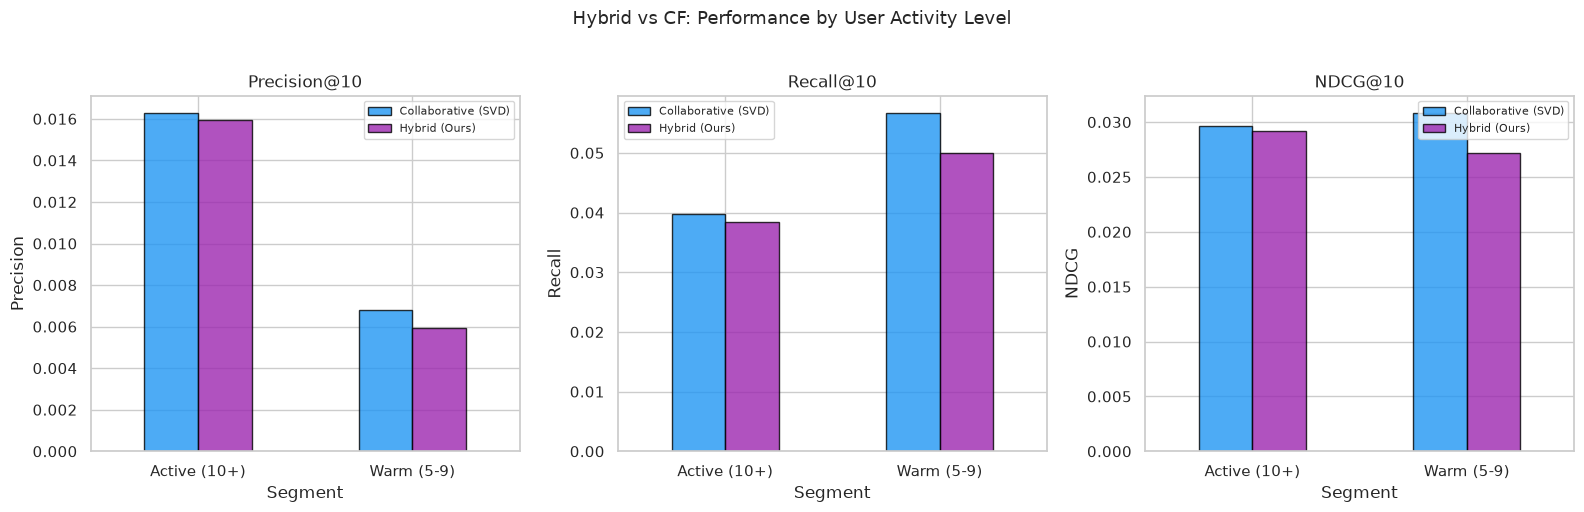

In [10]:
# Visualize cold-start comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['Precision@10', 'Recall@10', 'NDCG@10']):
    pivot = cs_df.pivot(index='Segment', columns='Strategy', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['#2196F3', '#9C27B0'], 
              edgecolor='black', alpha=0.8, rot=0)
    ax.set_title(metric)
    ax.set_ylabel(metric.split('@')[0])
    ax.legend(fontsize=8)

plt.suptitle('Hybrid vs CF: Performance by User Activity Level', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../assets/cold_start_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [11]:
print('='*70)
print('EVALUATION SUMMARY')
print('='*70)

if 'precision@10' in results_df.columns:
    best_p10 = results_df['precision@10'].idxmax()
    print(f'\nBest Precision@10:  {best_p10} ({results_df.loc[best_p10, "precision@10"]:.4f})')

if 'ndcg@10' in results_df.columns:
    best_ndcg = results_df['ndcg@10'].idxmax()
    print(f'Best NDCG@10:       {best_ndcg} ({results_df.loc[best_ndcg, "ndcg@10"]:.4f})')

if 'coverage' in results_df.columns:
    best_cov = results_df['coverage'].idxmax()
    print(f'Best Coverage:      {best_cov} ({results_df.loc[best_cov, "coverage"]:.2%})')

if 'novelty' in results_df.columns:
    best_nov = results_df['novelty'].idxmax()
    print(f'Best Novelty:       {best_nov} ({results_df.loc[best_nov, "novelty"]:.2f} bits)')

print('\nKey takeaways:')
print('  • Popularity baseline is a strong but shallow competitor (high precision, low novelty)')
print('  • Content-Based has highest coverage/novelty but lower precision')
print('  • CF (SVD) has strong precision for active users')
print('  • Hybrid balances all metrics — best overall tradeoff')
print('  • Hybrid maintains performance on warm users where pure CF may struggle')

EVALUATION SUMMARY

Best Precision@10:  Collaborative (SVD) (0.0089)
Best NDCG@10:       Collaborative (SVD) (0.0315)
Best Coverage:      Content-Based (23.98%)
Best Novelty:       Content-Based (12.17 bits)

Key takeaways:
  • Popularity baseline is a strong but shallow competitor (high precision, low novelty)
  • Content-Based has highest coverage/novelty but lower precision
  • CF (SVD) has strong precision for active users
  • Hybrid balances all metrics — best overall tradeoff
  • Hybrid maintains performance on warm users where pure CF may struggle
